# LAB04 - Geochemical Compositional Data Analysis

This laboratory demonstrates why multivariate geochemical concentration data
should be treated carefully when relative information, closure, censoring, and
log-ratio geometry matter.

The experiment uses a controlled synthetic geochemical dataset with ten
selected elements. The synthetic latent variables are retained only for
validation and teaching. They are not treated as information that would be
available in a real exploration campaign.

## Learning objectives

By the end of this laboratory, the reader should be able to:

- distinguish raw concentration analysis from compositional analysis;
- explain the effect of closure on correlation structure;
- apply CLR and ILR transformations to strictly positive data;
- understand why a D-part composition has D minus 1 effective dimensions;
- compare conventional PCA with PCA in Aitchison geometry;
- evaluate sensitivity to simple below-LOD replacement rules;
- interpret CLR loadings while avoiding direct elemental interpretation of
  basis-dependent ILR coordinates.


## Scientific scope and limitations

The dataset is fully synthetic. Concentrations follow a synthetic ppm
convention defined by the LAB04 data contract. Detection limits are experimental
assumptions rather than certified laboratory limits.

The ten selected elements form a **subcomposition**. Closing them to 100 is a
relative normalization used to study compositional geometry. It does not mean
that these ten elements constitute 100 percent of a physical rock sample.

Simple replacement by LOD divided by 2 is used as the primary pedagogical
baseline. LOD divided by the square root of 2 is used for sensitivity analysis.
Neither rule should be treated as a universally optimal solution for censored
geochemical data.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_lab_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "geochemistry_contract.json").exists():
        return cwd

    candidate = cwd / "labs" / "lab04_geochemical_coda"
    if (candidate / "geochemistry_contract.json").exists():
        return candidate

    raise FileNotFoundError("LAB04 directory could not be resolved.")


LAB_DIR = resolve_lab_dir()
DATA_DIR = LAB_DIR / "data"
RESULTS_DIR = LAB_DIR / "results"

with (LAB_DIR / "geochemistry_contract.json").open(
    encoding="utf-8"
) as handle:
    CONTRACT = json.load(handle)

ELEMENTS = CONTRACT["elements"]
LOD = pd.Series(CONTRACT["detection_limits"], dtype=float)

raw = pd.read_csv(DATA_DIR / "synthetic_geochemistry.csv")
analytical = pd.read_csv(RESULTS_DIR / "analytical_dataset.csv")
explained = pd.read_csv(RESULTS_DIR / "pca_explained_variance.csv")
raw_corr = pd.read_csv(RESULTS_DIR / "correlation_raw.csv", index_col=0)
closed_corr = pd.read_csv(
    RESULTS_DIR / "correlation_closed.csv", index_col=0
)
clr_corr = pd.read_csv(RESULTS_DIR / "correlation_clr.csv", index_col=0)
raw_loadings = pd.read_csv(
    RESULTS_DIR / "pca_loadings_raw.csv", index_col=0
)
clr_loadings = pd.read_csv(
    RESULTS_DIR / "pca_loadings_clr.csv", index_col=0
)
ilr_loadings = pd.read_csv(
    RESULTS_DIR / "pca_loadings_ilr.csv", index_col=0
)
lod_variance = pd.read_csv(
    RESULTS_DIR / "lod_sensitivity_variance.csv"
)
lod_scores = pd.read_csv(
    RESULTS_DIR / "lod_sensitivity_scores.csv"
)

with (RESULTS_DIR / "analysis_summary.json").open(
    encoding="utf-8"
) as handle:
    ANALYSIS_SUMMARY = json.load(handle)

with (RESULTS_DIR / "lod_sensitivity_summary.json").open(
    encoding="utf-8"
) as handle:
    LOD_SUMMARY = json.load(handle)

with (RESULTS_DIR / "data_contract_audit.json").open(
    encoding="utf-8"
) as handle:
    AUDIT_SUMMARY = json.load(handle)

print("LAB_DIR =", LAB_DIR)
print("RAW_ROWS =", len(raw))
print("ANALYTICAL_ROWS =", len(analytical))
print("ELEMENTS =", len(ELEMENTS))
print("UNIT =", CONTRACT["unit"])


LAB_DIR = /mnt/c/GeoAI/geoai-mineral-labs/labs/lab04_geochemical_coda
RAW_ROWS = 1200
ANALYTICAL_ROWS = 1092
ELEMENTS = 10
UNIT = ppm


## 1. Data contract and experiment design

The contract is the single source of truth for element ordering, synthetic
units, detection limits, closure semantics, replacement policies, CRS, and
latent-variable restrictions. This prevents analytical scripts from silently
using different assumptions.


In [2]:
contract_view = pd.DataFrame(
    {
        "element": ELEMENTS,
        "unit": CONTRACT["unit"],
        "detection_limit": [
            CONTRACT["detection_limits"][element]
            for element in ELEMENTS
        ],
    }
)

contract_view


,element,unit,detection_limit
0,Cu,ppm,30.0000
1,Mo,ppm,3.5000
2,Au,ppm,0.0105
3,As,ppm,4.8000
4,Sb,ppm,1.2000
5,Fe,ppm,3000.0000
6,Mg,ppm,1700.0000
7,Ca,ppm,1500.0000
8,Al,ppm,2500.0000
9,K,ppm,1150.0000


The coordinate reference system is EPSG:32719. The concentrations are synthetic
ppm values, and the closure total is a relative normalization constant rather
than a whole-rock percentage.


In [3]:
pd.Series(
    {
        "contract_version": CONTRACT["contract_version"],
        "samples": CONTRACT["expected_samples"],
        "crs": CONTRACT["crs"],
        "measurement_basis": CONTRACT["measurement_basis"],
        "unit": CONTRACT["unit"],
        "composition_scope": CONTRACT["composition_scope"],
        "whole_rock_composition": CONTRACT["whole_rock_composition"],
        "closure_total": CONTRACT["closure_total"],
    },
    name="LAB04 contract",
)


contract_version                                       1.0.0
samples                                                 1200
crs                                               EPSG:32719
measurement_basis               elemental_mass_concentration
unit                                                     ppm
composition_scope         selected_10_element_subcomposition
whole_rock_composition                                 False
closure_total                                          100.0
Name: LAB04 contract, dtype: object

## 2. Spatial structure of the synthetic survey

The synthetic coordinates are spatially continuous and contain embedded
porphyry-like and epithermal-like latent processes. The anomaly classes provide
an interpretable diagnostic target for visualization. They are not used to fit
the PCA models.


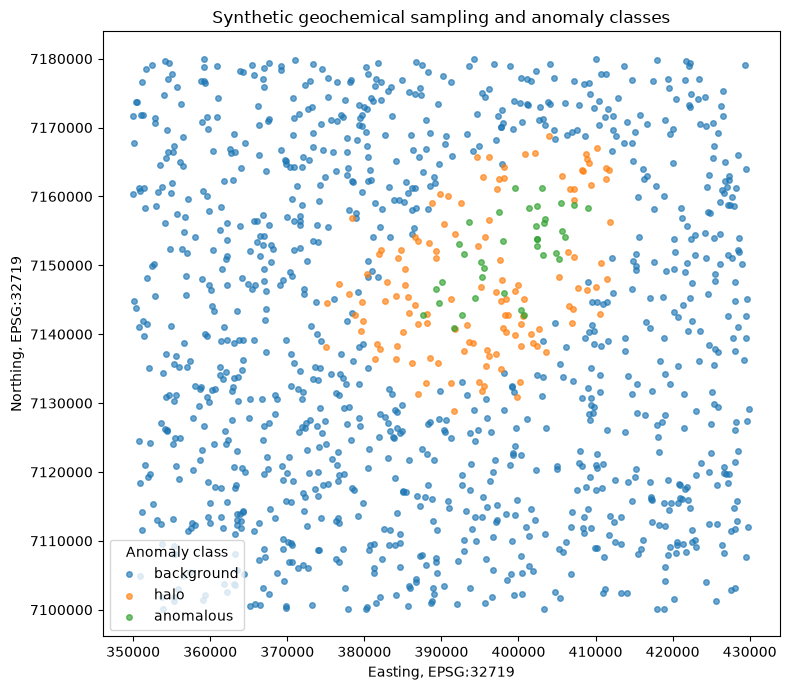

In [4]:
class_order = ["background", "halo", "anomalous"]

fig, ax = plt.subplots(figsize=(8, 7))
for label in class_order:
    subset = raw.loc[raw["anomaly_class"] == label]
    ax.scatter(
        subset["easting"],
        subset["northing"],
        s=16,
        alpha=0.65,
        label=label,
    )

ax.set_title("Synthetic geochemical sampling and anomaly classes")
ax.set_xlabel("Easting, EPSG:32719")
ax.set_ylabel("Northing, EPSG:32719")
ax.legend(title="Anomaly class")
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


## 3. Detection limits, censoring, and missing observations

A value encoded as zero represents a synthetic below-LOD observation. Missing
values remain separate as NaN. Keeping these mechanisms distinct is essential:
censoring contains partial information about concentration magnitude, whereas a
missing observation does not.


In [5]:
censor_counts = pd.Series(
    {
        element: int(raw[f"{element}_below_lod"].sum())
        for element in ELEMENTS
    },
    name="censored_count",
)

censor_table = pd.DataFrame(
    {
        "censored_count": censor_counts,
        "censored_rate": censor_counts / len(raw),
        "missing_count": raw[ELEMENTS].isna().sum(),
    }
)

censor_table


,censored_count,censored_rate,missing_count
Cu,157,0.130833,7
Mo,175,0.145833,16
Au,183,0.152500,9
As,143,0.119167,15
Sb,190,0.158333,7
Fe,43,0.035833,12
Mg,65,0.054167,12
Ca,61,0.050833,11
Al,85,0.070833,12
K,67,0.055833,10


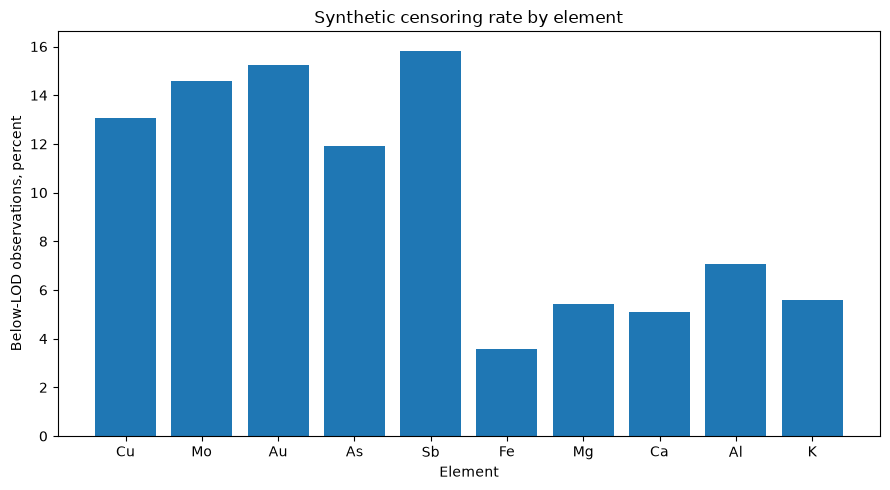

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(censor_table.index, 100 * censor_table["censored_rate"])
ax.set_title("Synthetic censoring rate by element")
ax.set_xlabel("Element")
ax.set_ylabel("Below-LOD observations, percent")
plt.tight_layout()
plt.show()


The complete-case analytical dataset contains 1,092 samples because 108 rows
contain at least one missing observed concentration. Below-LOD values are
replaced before the log-ratio transforms. Missing values are not imputed in this
laboratory.


In [7]:
pd.Series(
    {
        "input_rows": ANALYSIS_SUMMARY["input_rows"],
        "complete_rows": ANALYSIS_SUMMARY["complete_rows"],
        "excluded_missing_rows": ANALYSIS_SUMMARY[
            "excluded_missing_rows"
        ],
        "missing_cells": AUDIT_SUMMARY["missing_cells"],
        "censored_cells": AUDIT_SUMMARY["censored_cells"],
    },
    name="Data quality summary",
)


input_rows               1200
complete_rows            1092
excluded_missing_rows     108
missing_cells             111
censored_cells           1169
Name: Data quality summary, dtype: int64

## 4. Raw concentrations and relative closure

Raw concentrations are conventional measurements on their original numerical
scales. For the baseline PCA they are standardized because the elements occupy
very different numerical ranges.

Closure rescales every complete sample so that the selected ten-element
subcomposition sums to 100. Closure imposes a constant-sum constraint and can
alter ordinary correlation patterns. This is one reason that standard
Euclidean analysis of closed compositions can be misleading.


In [8]:
closed_columns = [f"{element}_closed" for element in ELEMENTS]
closed_sums = analytical[closed_columns].sum(axis=1)

pd.Series(
    {
        "minimum_closed_sum": closed_sums.min(),
        "maximum_closed_sum": closed_sums.max(),
        "mean_closed_sum": closed_sums.mean(),
    },
    name="Closure diagnostic",
)


minimum_closed_sum    100.0
maximum_closed_sum    100.0
mean_closed_sum       100.0
Name: Closure diagnostic, dtype: float64

## 5. Correlation structure before and after log-ratio transformation

Correlation is not used here as a score of methodological superiority. The goal
is to demonstrate that the representation changes the dependency structure.
CLR correlations describe associations among log-ratios relative to each
sample's geometric mean and should therefore be interpreted differently from
raw concentration correlations.


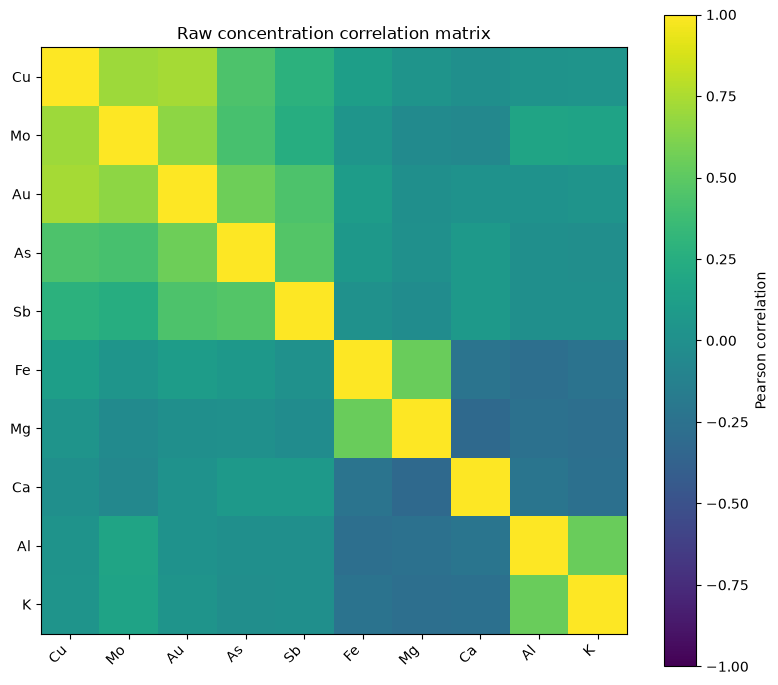

In [9]:
def plot_correlation(matrix: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(matrix.to_numpy(dtype=float), vmin=-1, vmax=1)
    positions = np.arange(len(matrix.columns))
    ax.set_xticks(positions, matrix.columns, rotation=45, ha="right")
    ax.set_yticks(positions, matrix.index)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Pearson correlation")
    plt.tight_layout()
    plt.show()


plot_correlation(raw_corr, "Raw concentration correlation matrix")


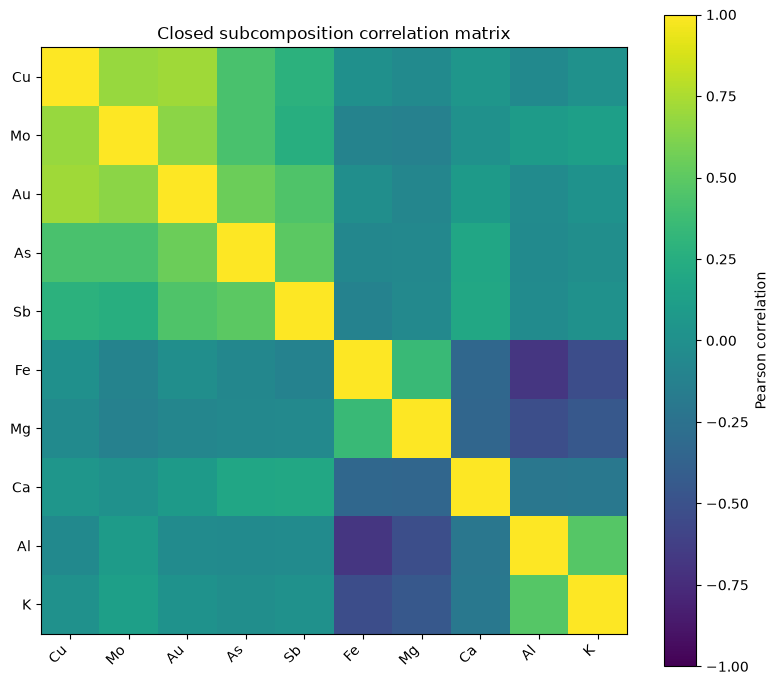

In [10]:
plot_correlation(
    closed_corr,
    "Closed subcomposition correlation matrix",
)


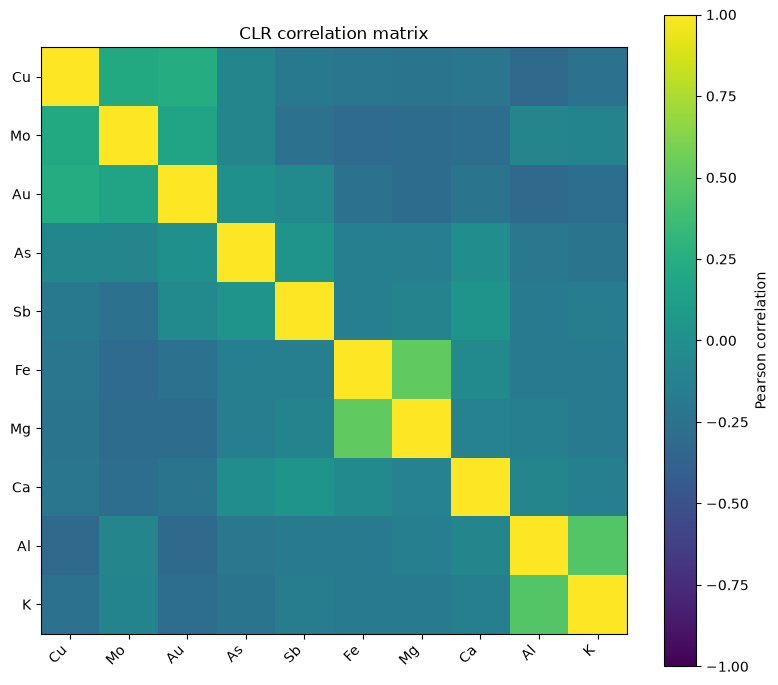

In [11]:
plot_correlation(clr_corr, "CLR correlation matrix")


Selected examples show how interpretation changes with representation. In this
synthetic experiment, Cu and Mo remain positively associated, while several
lithogenic relationships change magnitude after log-ratio transformation.
These differences are expected consequences of working in relative rather than
absolute geometry.


In [12]:
pairs = [
    ("Cu", "Mo"),
    ("Au", "As"),
    ("Au", "Sb"),
    ("Fe", "Mg"),
    ("Al", "K"),
]

pair_rows = []
for first, second in pairs:
    pair_rows.append(
        {
            "pair": f"{first}-{second}",
            "raw": raw_corr.loc[first, second],
            "closed": closed_corr.loc[first, second],
            "clr": clr_corr.loc[first, second],
        }
    )

pd.DataFrame(pair_rows).set_index("pair").round(3)


,raw,closed,clr
pair,,,
Cu-Mo,0.708,0.689,0.211
Au-As,0.556,0.552,0.001
Au-Sb,0.441,0.448,-0.046
Fe-Mg,0.544,0.353,0.512
Al-K,0.545,0.469,0.462


## 6. CLR and ILR geometry

The centered log-ratio transform maps each D-part composition to D coordinates,
but those coordinates sum to zero. Therefore the CLR representation has rank
D minus 1.

The isometric log-ratio transform provides D minus 1 orthonormal coordinates
and preserves Aitchison geometry without the CLR singularity. The numerical
meaning of an individual ILR coordinate depends on the chosen orthonormal
basis, so ILR loadings are not interpreted directly as elemental loadings in
this notebook.


In [13]:
pd.Series(
    {
        "number_of_parts": ANALYSIS_SUMMARY["elements"],
        "clr_dimension": ANALYSIS_SUMMARY["clr_dimension"],
        "clr_rank": ANALYSIS_SUMMARY["clr_rank"],
        "ilr_dimension": ANALYSIS_SUMMARY["ilr_dimension"],
        "clr_ilr_eigenvalues_match": ANALYSIS_SUMMARY[
            "coda_eigenvalues_match"
        ],
    },
    name="Aitchison geometry diagnostic",
)


number_of_parts                10
clr_dimension                  10
clr_rank                        9
ilr_dimension                   9
clr_ilr_eigenvalues_match    True
Name: Aitchison geometry diagnostic, dtype: object

## 7. PCA across representations

Four PCA variants are compared:

- raw concentrations standardized to unit variance;
- closed subcomposition standardized to unit variance;
- CLR coordinates without variance standardization;
- ILR coordinates without variance standardization.

The CLR and ILR analyses preserve the same non-zero Aitchison-space PCA
eigenvalues within numerical tolerance.


In [14]:
first_three = explained.loc[
    explained["component"].str.extract(r"PC(\d+)")[0].astype(int) <= 3
].copy()
first_three["percent"] = 100 * first_three[
    "explained_variance_ratio"
]

pivot_variance = first_three.pivot(
    index="component",
    columns="representation",
    values="percent",
)

pivot_variance


representation,closed,clr,ilr,raw
component,,,,
CLOSED_PC1,31.045325,NaN,NaN,NaN
CLOSED_PC2,24.772728,NaN,NaN,NaN
CLOSED_PC3,13.573497,NaN,NaN,NaN
CLR_PC1,NaN,22.559798,NaN,NaN
CLR_PC2,NaN,18.721529,NaN,NaN
CLR_PC3,NaN,15.131037,NaN,NaN
ILR_PC1,NaN,NaN,22.559798,NaN
ILR_PC2,NaN,NaN,18.721529,NaN
ILR_PC3,NaN,NaN,15.131037,NaN


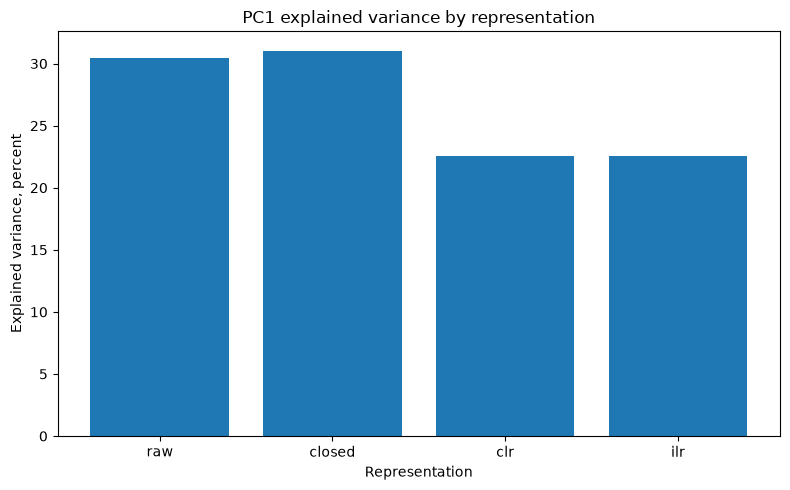

In [15]:
representations = ["raw", "closed", "clr", "ilr"]
pc1 = explained.loc[
    explained["component"].str.endswith("PC1"),
    ["representation", "explained_variance_ratio"],
].set_index("representation").loc[representations]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    pc1.index,
    100 * pc1["explained_variance_ratio"],
)
ax.set_title("PC1 explained variance by representation")
ax.set_xlabel("Representation")
ax.set_ylabel("Explained variance, percent")
plt.tight_layout()
plt.show()


## 8. PCA score spaces

The anomaly class is shown only after PCA has been computed. It acts as a
synthetic diagnostic overlay and is not included among the PCA input features.
This separation avoids target leakage in the unsupervised analysis.


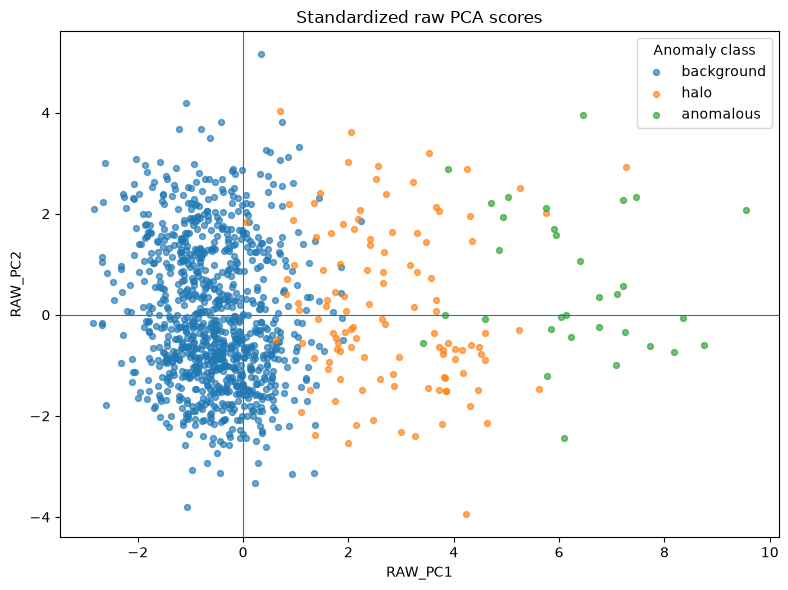

In [16]:
def plot_scores(
    frame: pd.DataFrame,
    x_column: str,
    y_column: str,
    title: str,
) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    for label in class_order:
        subset = frame.loc[frame["anomaly_class"] == label]
        ax.scatter(
            subset[x_column],
            subset[y_column],
            s=18,
            alpha=0.65,
            label=label,
        )
    ax.axhline(0.0, linewidth=0.8)
    ax.axvline(0.0, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(x_column)
    ax.set_ylabel(y_column)
    ax.legend(title="Anomaly class")
    plt.tight_layout()
    plt.show()


plot_scores(
    analytical,
    "RAW_PC1",
    "RAW_PC2",
    "Standardized raw PCA scores",
)


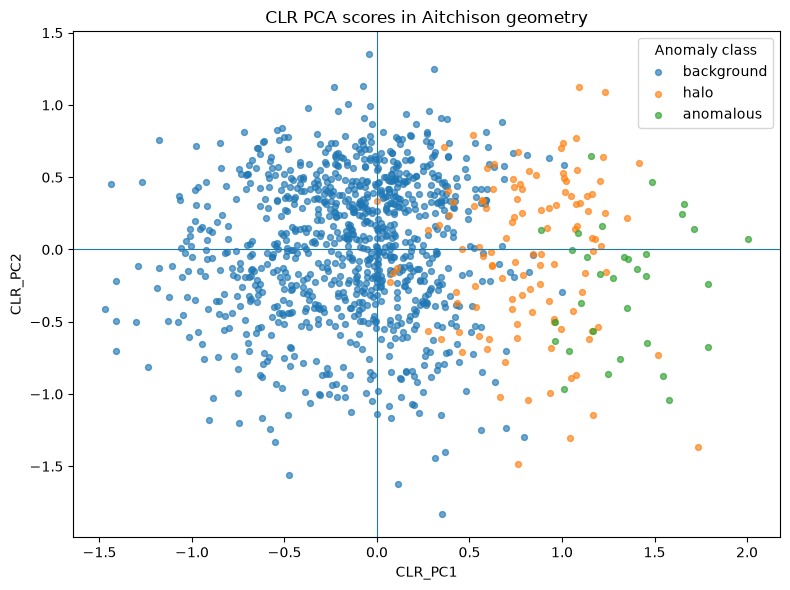

In [17]:
plot_scores(
    analytical,
    "CLR_PC1",
    "CLR_PC2",
    "CLR PCA scores in Aitchison geometry",
)


## 9. Element-level PCA loadings

Raw and CLR loadings can be displayed against named elements. PCA signs are
arbitrary: reversing every loading and score on one component represents the
same solution. Interpretation therefore focuses on relative groups and
contrasts rather than the absolute sign alone.

ILR loadings are basis-coordinate loadings and are intentionally not used for
direct element-level geological interpretation.


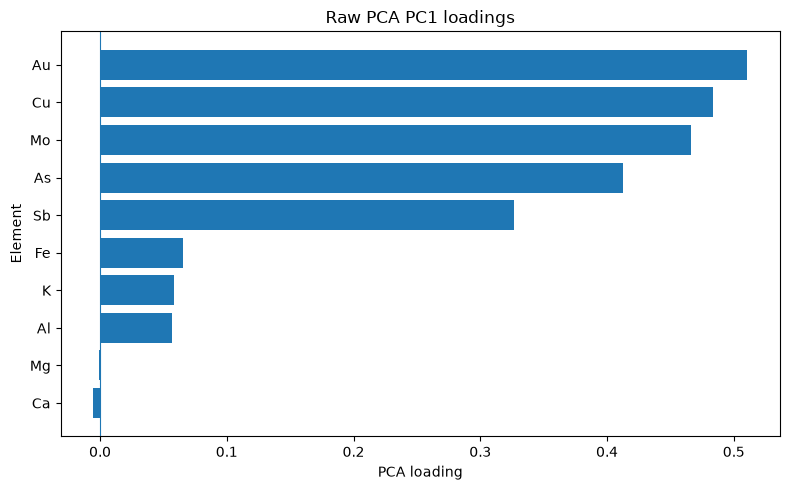

In [18]:
def plot_loadings(
    loadings: pd.DataFrame,
    component: str,
    title: str,
) -> None:
    values = loadings[component].sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(values.index, values.to_numpy())
    ax.axvline(0.0, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("PCA loading")
    ax.set_ylabel("Element")
    plt.tight_layout()
    plt.show()


plot_loadings(
    raw_loadings,
    "RAW_PC1",
    "Raw PCA PC1 loadings",
)


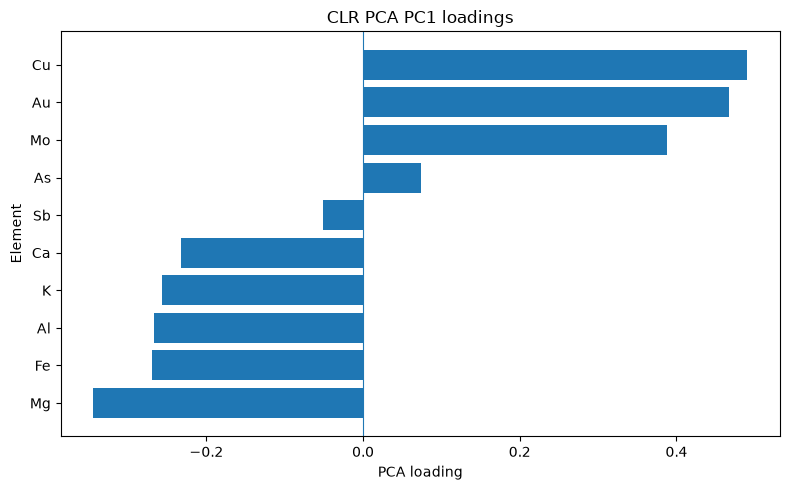

In [19]:
plot_loadings(
    clr_loadings,
    "CLR_PC1",
    "CLR PCA PC1 loadings",
)


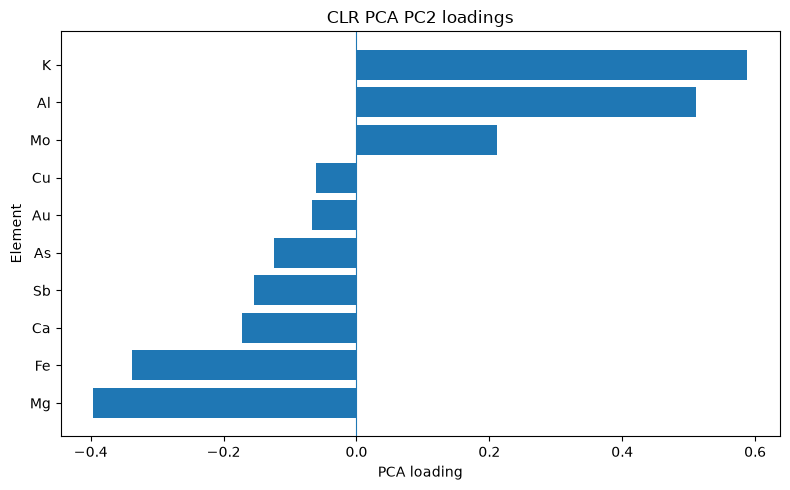

In [20]:
plot_loadings(
    clr_loadings,
    "CLR_PC2",
    "CLR PCA PC2 loadings",
)


In this controlled experiment, CLR PC1 contrasts a Cu-Mo-Au-rich signature
against several lithogenic components, while CLR PC2 expresses a strong
Al-K versus Fe-Mg contrast. These patterns are consistent with the latent
structure intentionally embedded in the synthetic generator, but they should
not be generalized to real deposits without independent geological evidence.


## 10. Sensitivity to below-LOD replacement

The primary analysis uses LOD divided by 2. A second run uses LOD divided by the
square root of 2. The first three CLR PCA score vectors remain highly
correlated, but explained-variance ratios change enough to justify reporting
the sensitivity analysis explicitly.


In [21]:
pd.Series(
    {
        "common_samples": LOD_SUMMARY["common_samples"],
        "pc1_score_correlation": LOD_SUMMARY[
            "pc1_score_correlation"
        ],
        "pc2_score_correlation": LOD_SUMMARY[
            "pc2_score_correlation"
        ],
        "pc3_score_correlation": LOD_SUMMARY[
            "pc3_score_correlation"
        ],
        "pc1_variance_difference": LOD_SUMMARY[
            "pc1_explained_variance_absolute_difference"
        ],
    },
    name="LOD sensitivity summary",
)


common_samples             1092.000000
pc1_score_correlation         0.983686
pc2_score_correlation         0.981298
pc3_score_correlation         0.954433
pc1_variance_difference       0.020898
Name: LOD sensitivity summary, dtype: float64

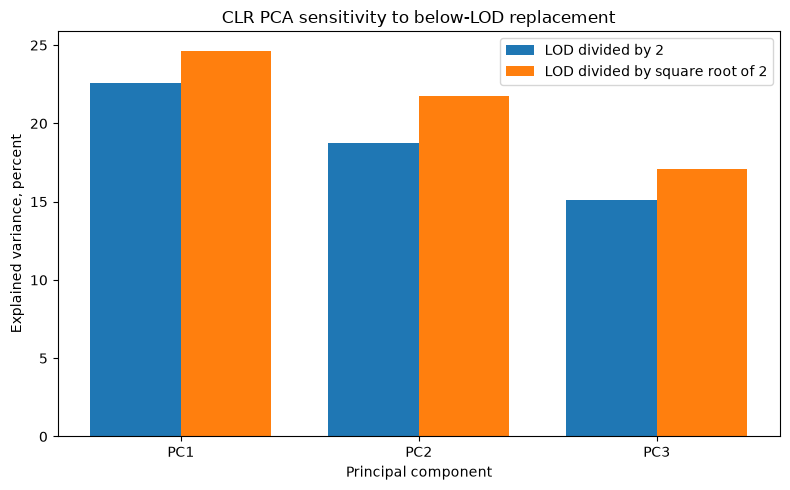

In [22]:
variance_plot = lod_variance.loc[
    lod_variance["component"].isin(["PC1", "PC2", "PC3"])
].copy()
variance_plot["percent"] = 100 * variance_plot[
    "explained_variance_ratio"
]

components = ["PC1", "PC2", "PC3"]
x = np.arange(len(components))
width = 0.38

half = variance_plot.loc[
    variance_plot["replacement_rule"] == "lod_half"
].set_index("component").loc[components, "percent"]
sqrt2 = variance_plot.loc[
    variance_plot["replacement_rule"] == "lod_sqrt2"
].set_index("component").loc[components, "percent"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, half, width, label="LOD divided by 2")
ax.bar(
    x + width / 2,
    sqrt2,
    width,
    label="LOD divided by square root of 2",
)
ax.set_xticks(x, components)
ax.set_title("CLR PCA sensitivity to below-LOD replacement")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance, percent")
ax.legend()
plt.tight_layout()
plt.show()


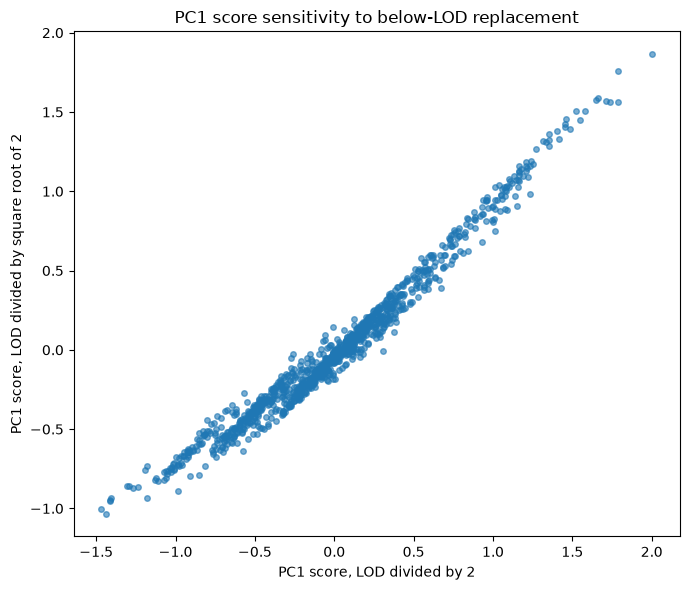

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    lod_scores["PC1_lod_half"],
    lod_scores["PC1_lod_sqrt2"],
    s=16,
    alpha=0.6,
)
ax.set_title("PC1 score sensitivity to below-LOD replacement")
ax.set_xlabel("PC1 score, LOD divided by 2")
ax.set_ylabel("PC1 score, LOD divided by square root of 2")
plt.tight_layout()
plt.show()


The score correlations support structural stability of the leading PCA patterns
under the two simple replacement rules. However, the explained variance changes
by about two percentage points for PC1. The appropriate conclusion is therefore
**partial robustness**, not complete insensitivity to censoring treatment.


## 11. Ground-truth diagnostics without leakage

Synthetic latent variables allow us to verify whether the analysis responds to
the processes used to generate the data. This is a simulation-only diagnostic.
A real exploration dataset would not provide latent mineralization,
pathfinder, or alteration fields.

Future predictive models must therefore keep these columns outside the feature
matrix unless the explicit objective is simulation validation.


In [24]:
diagnostic_columns = [
    "CLR_PC1",
    "CLR_PC2",
    "CLR_PC3",
    "latent_mineralization",
    "latent_pathfinder",
    "latent_alteration",
]

analytical[diagnostic_columns].corr().round(3)


,CLR_PC1,CLR_PC2,CLR_PC3,latent_mineralization,latent_pathfinder,latent_alteration
CLR_PC1,1.000,-0.000,0.000,0.796,0.527,0.699
CLR_PC2,-0.000,1.000,-0.000,-0.042,-0.116,-0.054
CLR_PC3,0.000,-0.000,1.000,-0.126,0.159,-0.078
latent_mineralization,0.796,-0.042,-0.126,1.000,0.561,0.872
latent_pathfinder,0.527,-0.116,0.159,0.561,1.000,0.593
latent_alteration,0.699,-0.054,-0.078,0.872,0.593,1.000


## 12. Main methodological findings

1. Closure introduces a constant-sum constraint and materially changes ordinary
   correlation structure.
2. CLR provides element-labelled log-ratio coordinates that are useful for
   interpretation but are singular in D dimensions.
3. ILR provides D minus 1 orthonormal coordinates suitable for Euclidean
   algorithms while preserving Aitchison geometry.
4. CLR and ILR PCA share the same non-zero eigenvalues in this implementation.
5. The leading CLR components recover the synthetic metallogenic and lithogenic
   contrasts embedded in the generator.
6. Simple below-LOD replacement affects the amount of variance attributed to
   the leading components even when the broad score structure remains stable.


## 13. Limitations and next steps

This laboratory is a proof of concept rather than a complete geochemical
workflow. Important extensions include:

- multivariate or model-based methods for censored compositions;
- explicit treatment of laboratory uncertainty and heterogeneous analytical
  methods;
- spatially structured validation rather than random validation;
- subcompositional sensitivity analysis when the element panel changes;
- geologically informed balances when interpretable ILR coordinates are
  required;
- integration with geology, geophysics, remote sensing, and spatial covariates.

LAB05 will use the lessons from this experiment to build a mineral prospectivity
mapping workflow while preserving spatial validation and leakage controls.


## Reproducibility statement

LAB04 is generated from deterministic source code with seed 12345. The data
contract centralizes scientific assumptions. The pipeline includes unit tests,
contract auditing, numerical regression checks, SHA-256 reproducibility checks,
pre-commit validation, and secret scanning.

The latent fields and anomaly labels are synthetic diagnostic information only.
No real exploration data are included in this laboratory.
